# Cycling Expansion Derating

2025/04/30

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils
from src import simutils as simutils
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

%load_ext autoreload
%matplotlib widget
plotter.initialize(plt)

target_dir = os.getcwd()

# Load the experimental data

In [2]:
expt1, df1 = ioutils.fetch_experimental_data(152064, to_include_cycling=True)
# expt2, df2 = ioutils.fetch_experimental_data(152074)
expt3, df3 = ioutils.fetch_experimental_data(152071, to_include_cycling=True)
expt4, df4 = ioutils.fetch_experimental_data(152098, to_include_cycling=True)

In [3]:
# With optimal d_ec and d_vc values
d_ec_opt1 = 3.2e-20  # Optimal d_ec for base
d_ec_opt2 = 3.2e-20  # Optimal d_ec for fast
d_ec_opt3 = 5.1e-20  # Optimal d_ec for fast+
d_vc_opt1 = 4.2e-16  # Optimal d_vc for base
d_vc_opt2 = 3.2e-17  # Optimal d_vc for fast
d_vc_opt3 = 3.2e-17  # Optimal d_vc for fast+

df_sim1 = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, dt=5, include_flag=False)
df_sim1d = simutils.run_sim('base', d_ec_opt1, d_vc_opt1, dt=5, include_flag=False, dsei_derating_cycling=1e-1)
df_sim2 = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, dt=1, include_flag=False)
df_sim2d = simutils.run_sim('fast', d_ec_opt2, d_vc_opt2, dt=5, include_flag=False, dsei_derating_cycling=1e-1)
df_sim3 = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, dt=5, include_flag=False)
df_sim3d = simutils.run_sim('fast+', d_ec_opt3, d_vc_opt3, dt=1, include_flag=False, dsei_derating_cycling=1e-1)

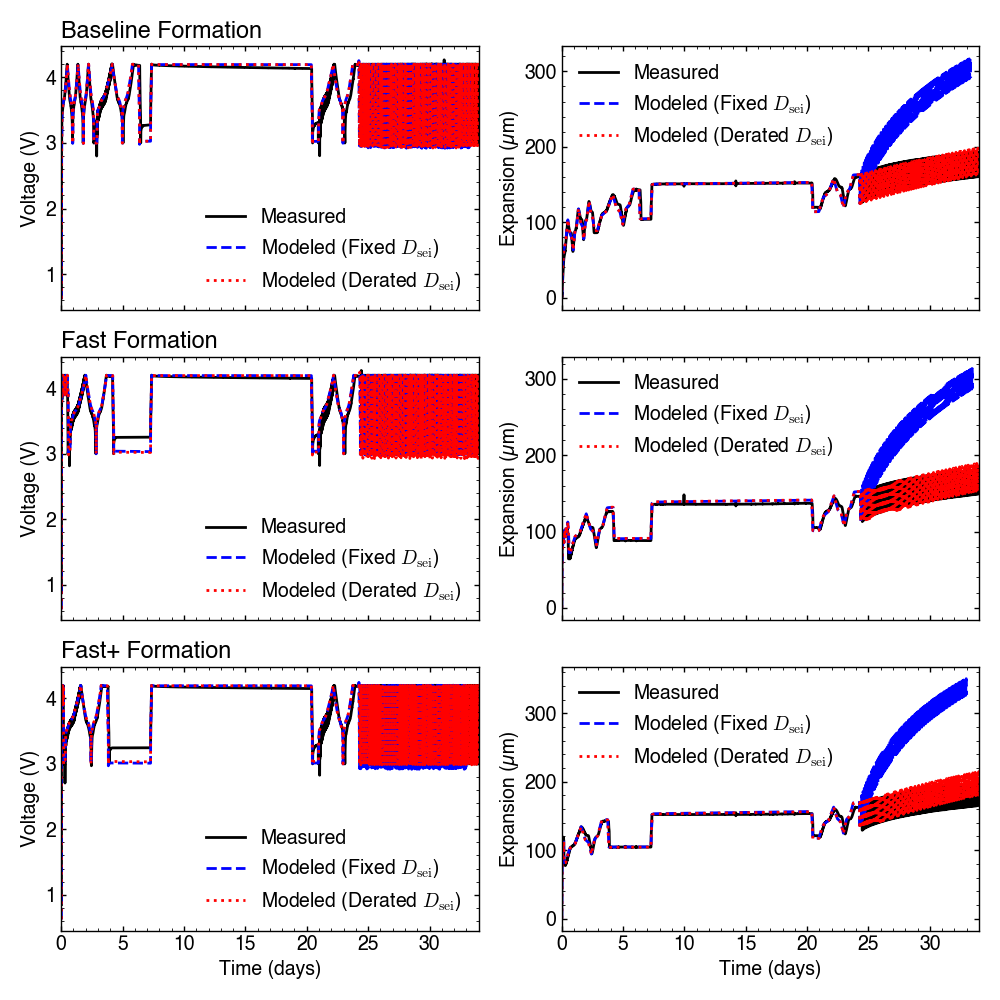

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(10, 10), sharex=True)

axs[0,0].plot(expt1['arbin_time']/3600/24, expt1['arbin_voltage'], label='Measured', color='black')
axs[0,0].plot(df_sim1['t']/3600/24, df_sim1['vt'], label=r'Modeled (Fixed $D_\mathrm{sei}$)', color='blue', ls='--')
axs[0,0].plot(df_sim1d['t']/3600/24, df_sim1d['vt'], label=r'Modeled (Derated $D_\mathrm{sei}$)', color='red', ls=':')
axs[0,0].set_ylabel('Voltage (V)')
axs[0,0].legend(loc='lower right')
axs[0,0].grid(False)
axs[0,0].set_title('Baseline Formation', loc='left')

axs[0,1].plot(expt1['daq_time']/3600/24, expt1['daq_strain'], label='Measured', color='black')
axs[0,1].plot(df_sim1['t']/3600/24, 1e6*df_sim1['expansion'], label=r'Modeled (Fixed $D_\mathrm{sei}$)', color='blue', ls='--')
axs[0,1].plot(df_sim1d['t']/3600/24, 1e6*df_sim1d['expansion'], label=r'Modeled (Derated $D_\mathrm{sei}$)', color='red', ls=':')
axs[0,1].set_ylabel('Expansion (µm)')
axs[0,1].grid(False)
axs[0,1].legend(loc='upper left')
axs[0,1].set_xlim(0, 34)

axs[1,0].plot(expt3['arbin_time']/3600/24, expt3['arbin_voltage'], label='Measured', color='black')
axs[1,0].plot(df_sim2['t']/3600/24, df_sim2['vt'], label=r'Modeled (Fixed $D_\mathrm{sei}$)', color='blue', ls='--')
axs[1,0].plot(df_sim2d['t']/3600/24, df_sim2d['vt'], label=r'Modeled (Derated $D_\mathrm{sei}$)', color='red', ls=':')
axs[1,0].set_ylabel('Voltage (V)')
axs[1,0].grid(False)    
axs[1,0].set_title('Fast Formation', loc='left')

axs[1,0].legend(loc='lower right')
axs[1,1].plot(expt3['daq_time']/3600/24, expt3['daq_strain'], label='Measured', color='black')
axs[1,1].plot(df_sim2['t']/3600/24, 1e6*df_sim2['expansion'], label=r'Modeled (Fixed $D_\mathrm{sei}$)', color='blue', ls='--')
axs[1,1].plot(df_sim2d['t']/3600/24, 1e6*df_sim2d['expansion'], label=r'Modeled (Derated $D_\mathrm{sei}$)', color='red', ls=':')
axs[1,1].set_ylabel('Expansion (µm)')
axs[1,1].grid(False)
axs[1,1].legend(loc='upper left')
axs[1,1].set_xlim(0, 34)    

axs[2,0].plot(expt4['arbin_time']/3600/24, expt4['arbin_voltage'], label='Measured', color='black')
axs[2,0].plot(df_sim3['t']/3600/24, df_sim3['vt'], label=r'Modeled (Fixed $D_\mathrm{sei}$)', color='blue', ls='--')
axs[2,0].plot(df_sim3d['t']/3600/24, df_sim3d['vt'], label=r'Modeled (Derated $D_\mathrm{sei}$)', color='red', ls=':')
axs[2,0].set_ylabel('Voltage (V)')
axs[2,0].grid(False)
axs[2,0].legend(loc='lower right')
axs[2,0].set_title('Fast+ Formation', loc='left')
axs[2,0].set_xlabel('Time (days)')

axs[2,1].plot(expt4['daq_time']/3600/24, expt4['daq_strain'], label='Measured', color='black')
axs[2,1].plot(df_sim3['t']/3600/24, 1e6*df_sim3['expansion'], label=r'Modeled (Fixed $D_\mathrm{sei}$)', color='blue', ls='--')
axs[2,1].plot(df_sim3d['t']/3600/24, 1e6*df_sim3d['expansion'], label=r'Modeled (Derated $D_\mathrm{sei}$)', color='red', ls=':')
axs[2,1].set_ylabel('Expansion (µm)')
axs[2,1].legend(loc='upper left')
axs[2,1].grid(False)
axs[2,1].set_xlabel('Time (days)')
axs[2,1].set_xlim(0, 34)    

plt.savefig('outputs/figures/dsei_derating.svg', format='svg', dpi=300)

plt.tight_layout()
plt.show()